In [53]:
import os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from datasets import Dataset
from collections import Counter

from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score,
)

In [54]:
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 6)

MODEL_ROOT = os.path.abspath(os.path.join("..", "..", "models"))
MODEL_FAMILY = "Desbalance"  # Cambia a "Undersampling" o "VAE"
MODEL_VARIANT = "codigos"   # Cambia a "descripciones" o "combinado" o deja None para todos

print("Modelo raíz:", MODEL_ROOT)
print("Familia de dataset elegida:", MODEL_FAMILY)
print("Variante de modelo elegida:", MODEL_VARIANT)

DATA_PATH = os.path.abspath(os.path.join("..", "..", "TFG", "dataset", "dataset_finales", "Desbalance", "Dataset_procesable.csv"))
print("Ruta de datos de prueba esperada:", DATA_PATH)

# Ajusta las columnas de entrada y de etiqueta según tu caso
TEXT_COLUMN = "Diag \d{2} (Principal|Secundario)\s+\(cod\)"
LABEL_COLUMN = "DIAG PSQ"


# Si tus modelos son de clasificación binaria, deja LABELS = None.
# Para multiclase, define la lista de etiquetas reales de tu problema.
LABELS = ["F20", "F21", "F22", "F23", "F25", "F29", "F60.1"]


def model_variant_from_dir(model_dir):
    name = os.path.basename(model_dir).lower()
    if "codigos" in name:
        return "codigos"
    if "descripciones" in name:
        return "descripciones"
    if "combinado" in name:
        return "combinado"

    json_path = os.path.join(model_dir, "training_results.json")
    if os.path.exists(json_path):
        try:
            with open(json_path, "r", encoding="utf-8") as f:
                data = json.load(f)
            ds = data.get("dataset") or data.get("dataset_type") or data.get("data")
            if isinstance(ds, str):
                ds = ds.lower()
                if "codigos" in ds:
                    return "codigos"
                if "descripciones" in ds:
                    return "descripciones"
                if "combinado" in ds:
                    return "combinado"
        except Exception:
            pass
    return None


def find_saved_model_dirs(root_path, variant=None):
    model_dirs = []
    for root, dirs, files in os.walk(root_path):
        if any(name in files for name in ["config.json", "pytorch_model.bin", "tf_model.h5", "model.h5"]):
            if variant is not None:
                variant_value = model_variant_from_dir(root)
                if variant_value != variant:
                    continue
            model_dirs.append(root)
    return sorted(set(model_dirs))

family_root = os.path.join(MODEL_ROOT, MODEL_FAMILY)
if not os.path.exists(family_root):
    raise FileNotFoundError(f"No existe la carpeta de familia de modelos: {family_root}")

saved_models = find_saved_model_dirs(family_root, variant=MODEL_VARIANT)
print("Modelos encontrados:")
for m in saved_models:
    print("-", m)

try:
    import tensorflow as tf
    from tensorflow.keras.models import load_model as load_keras_model
except ImportError:
    tf = None

try:
    import torch
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
except ImportError:
    torch = None
    AutoTokenizer = None
    AutoModelForSequenceClassification = None

Modelo raíz: c:\Users\Usuario\Documents\Workspace\Mirage\models
Familia de dataset elegida: Desbalance
Variante de modelo elegida: codigos
Ruta de datos de prueba esperada: c:\Users\Usuario\Documents\Workspace\Mirage\TFG\dataset\dataset_finales\Desbalance\Dataset_procesable.csv
Modelos encontrados:
- c:\Users\Usuario\Documents\Workspace\Mirage\models\Desbalance\dccuchile_bert-base-spanish-wwm-cased_codigos_final


<>:16: SyntaxWarning: invalid escape sequence '\d'
<>:16: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Usuario\AppData\Local\Temp\ipykernel_6316\1552898050.py:16: SyntaxWarning: invalid escape sequence '\d'
  TEXT_COLUMN = "Diag \d{2} (Principal|Secundario)\s+\(cod\)"


In [55]:
def is_transformers_model(path):
    return os.path.exists(os.path.join(path, "config.json")) and os.path.exists(os.path.join(path, "tokenizer.json"))


def is_keras_model(path):
    if os.path.isdir(path):
        return any(os.path.exists(os.path.join(path, fname)) for fname in ["model.h5", "saved_model.pb"])
    return path.endswith(".h5")


def is_torch_model(path):
    return any(path.endswith(ext) for ext in [".pt", ".pth"]) or os.path.exists(os.path.join(path, "pytorch_model.bin"))


def load_saved_model(path):
    if is_transformers_model(path):
        if AutoTokenizer is None or AutoModelForSequenceClassification is None:
            raise RuntimeError("Instala transformers y torch para cargar modelos Hugging Face")
        tokenizer = AutoTokenizer.from_pretrained(path)
        model = AutoModelForSequenceClassification.from_pretrained(path)
        model.eval()
        return {"type": "transformers", "path": path, "model": model, "tokenizer": tokenizer}

    if is_keras_model(path):
        if tf is None:
            raise RuntimeError("Instala tensorflow para cargar modelos Keras")
        model = load_keras_model(path)
        return {"type": "keras", "path": path, "model": model}

    if is_torch_model(path):
        if torch is None:
            raise RuntimeError("Instala torch para cargar modelos PyTorch")
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        if os.path.isdir(path):
            candidate = os.path.join(path, "pytorch_model.bin")
        else:
            candidate = path
        model = torch.load(candidate, map_location=device)
        model.eval()
        return {"type": "torch", "path": path, "model": model, "device": device}

    raise ValueError(f"No se reconoce el formato de modelo en: {path}")

def softmax(x):
    e = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)


def predict_keras(model, X):
    y_pred = model.predict(X, batch_size=32)
    if y_pred.ndim == 1:
        y_pred = np.vstack([1 - y_pred, y_pred]).T
    return y_pred


def predict_transformers(model, tokenizer, texts, device=None):
    from transformers import logging
    logging.set_verbosity_error()
    if isinstance(texts, (pd.Series, np.ndarray)):
        texts = texts.astype(str).tolist()
    elif isinstance(texts, str):
        texts = [texts]
    else:
        texts = [str(t) for t in texts]

    encoded = tokenizer(
        texts,
        padding=True,
        truncation=True,
        return_tensors="pt",
        max_length=256,
    )
    if device is not None:
        encoded = {k: v.to(device) for k, v in encoded.items()}
        model = model.to(device)
    with torch.no_grad():
        outputs = model(**encoded)
    scores = outputs.logits.detach().cpu().numpy()
    return softmax(scores)


def predict_torch(model, X, device=None):
    model = model.to(device) if device is not None else model
    with torch.no_grad():
        if isinstance(X, dict):
            X = {k: v.to(device) for k, v in X.items()}
            outputs = model(**X)
        else:
            X = torch.tensor(X, dtype=torch.float32).to(device)
            outputs = model(X)
    logits = outputs.logits if hasattr(outputs, "logits") else outputs
    y_scores = logits.detach().cpu().numpy()
    return softmax(y_scores)


def predict_model(saved, X):
    if saved["type"] == "keras":
        return predict_keras(saved["model"], X)
    if saved["type"] == "transformers":
        return predict_transformers(saved["model"], saved["tokenizer"], X, device=saved.get("device"))
    if saved["type"] == "torch":
        return predict_torch(saved["model"], X, device=saved.get("device"))
    raise ValueError("Tipo de modelo no soportado")

In [56]:
df = pd.read_csv(DATA_PATH, encoding="utf-8", sep="|")

# Fusiona columnas de diagnóstico en texto
diag_cols = [col for col in df.columns if col.startswith("Diag")]
df["text"] = df[diag_cols].fillna("").apply(lambda x: " ".join(x), axis=1)

# etiquetas válidas en el conjunto completo
codes = ["F20", "F21", "F22", "F23", "F25", "F29", "F60.1"]
# quedarnos sólo con esas filas y convertir el código a un entero
df = df[df["DIAG PSQ"].isin(codes)].copy()
df["label"] = df["DIAG PSQ"].astype("category").cat.codes

seed = 42
np.random.seed(seed)

# División en train/test
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"],
    stratify=df["label"], test_size=0.2, random_state=seed
)
train_dataset = Dataset.from_dict({"text": X_train.tolist(), "label": y_train.tolist()})
test_dataset = Dataset.from_dict({"text": X_test.tolist(), "label": y_test.tolist()})
print("Entrenamiento:", Counter(y_train))
print("Evaluación:", Counter(y_test))

Entrenamiento: Counter({0: 1316, 2: 216, 5: 119, 4: 88, 3: 56, 6: 10, 1: 6})
Evaluación: Counter({0: 329, 2: 54, 5: 30, 4: 22, 3: 14, 6: 3, 1: 1})


In [57]:
# Carga de datos de prueba
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"No se encontró el dataset de prueba en {DATA_PATH}")

try:
    df_test = pd.read_csv(DATA_PATH, encoding="utf-8", sep="|")
except Exception as e:
    raise RuntimeError(f"Error al leer el archivo de datos: {e}")

if TEXT_COLUMN not in df_test.columns:
    diag_cols = [col for col in df_test.columns if col.startswith("Diag")]
    if len(diag_cols) > 0:
        df_test["text"] = df_test[diag_cols].fillna("").astype(str).apply(lambda row: " ".join(row), axis=1)
        TEXT_COLUMN = "text"
    else:
        raise ValueError(
            f"La columna de texto '{TEXT_COLUMN}' no se encuentra en el dataset de prueba "
            "y no se pudieron construir textos desde columnas Diag"
        )

if LABEL_COLUMN not in df_test.columns:
    raise ValueError(f"La columna de etiqueta '{LABEL_COLUMN}' no se encuentra en el dataset de prueba")

print(f"Datos de prueba: {len(df_test)} filas")
print(df_test.head())

label_values = df_test[LABEL_COLUMN]
if LABELS is None:
    LABELS = sorted(label_values.astype(str).unique())
    print("Etiquetas detectadas:", LABELS)

binary_classification = len(LABELS) == 2

X_test = [str(x) for x in df_test[TEXT_COLUMN].tolist()]

y_test = label_values.tolist()

if not isinstance(y_test[0], str):
    y_test = [str(int(x)) if pd.notna(x) else "" for x in y_test]


Datos de prueba: 2264 filas
  Diag 01 Principal    (cod) Diag 02 Secundario    (cod)  \
0                     R78.81                      B96.20   
1                        F70                       F25.9   
2                        NaN                      Z98.84   
3                        NaN                       E78.5   
4                     J10.00                      J96.92   

  Diag 03 Secundario    (cod) Diag 04 Secundario    (cod)  \
0                       C25.9                       C78.7   
1                         NaN                         NaN   
2                         NaN                         NaN   
3                      Z90.49                       Z88.8   
4                       D50.9                       E66.2   

  Diag 05 Secundario    (cod) Diag 06 Secundario    (cod)  \
0                       Z74.3                         NaN   
1                         NaN                         NaN   
2                         NaN                         NaN   


In [58]:

# Evaluación de modelos
results = []
roc_data = []

for model_dir in saved_models:
    print("Cargando modelo:", model_dir)
    saved = load_saved_model(model_dir)

    if saved["type"] == "keras":
        try:
            y_scores = predict_model(saved, X_test)
        except Exception:
            raise RuntimeError("Ajusta la entrada del modelo Keras en predict_model para tus datos")
    else:
        y_scores = predict_model(saved, X_test)

    if y_scores.ndim == 1:
        y_scores = np.vstack([1 - y_scores, y_scores]).T

    y_pred = np.argmax(y_scores, axis=1)

    label_index = {label: idx for idx, label in enumerate(LABELS)}
    y_true_idx = []
    for y in y_test:
        if isinstance(y, (int, np.integer)):
            y_key = str(int(y))
        else:
            y_key = str(y)
        if y_key not in label_index:
            raise ValueError(
                f"Etiqueta desconocida en y_test: {y} -> '{y_key}'. "
                f"Etiquetas válidas: {LABELS}"
            )
        y_true_idx.append(label_index[y_key])
    y_true_idx = np.array(y_true_idx, dtype=int)

    report = classification_report(y_true_idx, y_pred, target_names=LABELS, output_dict=True, zero_division=0)
    accuracy = accuracy_score(y_true_idx, y_pred)
    precision = precision_score(y_true_idx, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true_idx, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true_idx, y_pred, average="weighted", zero_division=0)

    n_scores = y_scores.shape[1]
    if binary_classification:
        if n_scores < 2:
            roc_auc = np.nan
            print(
                f"Advertencia: modelo {os.path.basename(model_dir)} devuelve {n_scores} salidas para clasificación binaria. "
                "No se puede calcular ROC AUC binaria."
            )
        else:
            roc_auc = roc_auc_score(y_true_idx, y_scores[:, 1])
    else:
        if n_scores == len(LABELS):
            y_binarized = label_binarize(y_true_idx, classes=list(range(len(LABELS))))
            roc_auc = roc_auc_score(y_binarized, y_scores, average="weighted", multi_class="ovr")
        else:
            roc_auc = np.nan
            print(
                f"Advertencia: modelo {os.path.basename(model_dir)} devuelve {n_scores} salidas "
                f"pero se esperaba {len(LABELS)} etiquetas. ROC AUC multiclase se omitirá."
            )

    results.append({
        "model": os.path.basename(model_dir),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "num_outputs": n_scores,
    })

    roc_data.append({
        "model": os.path.basename(model_dir),
        "y_true": y_true_idx,
        "y_scores": y_scores,
    })
results_df = pd.DataFrame(results).sort_values("f1_score", ascending=False)

Cargando modelo: c:\Users\Usuario\Documents\Workspace\Mirage\models\Desbalance\dccuchile_bert-base-spanish-wwm-cased_codigos_final
Advertencia: modelo dccuchile_bert-base-spanish-wwm-cased_codigos_final devuelve 2 salidas pero se esperaba 7 etiquetas. ROC AUC multiclase se omitirá.


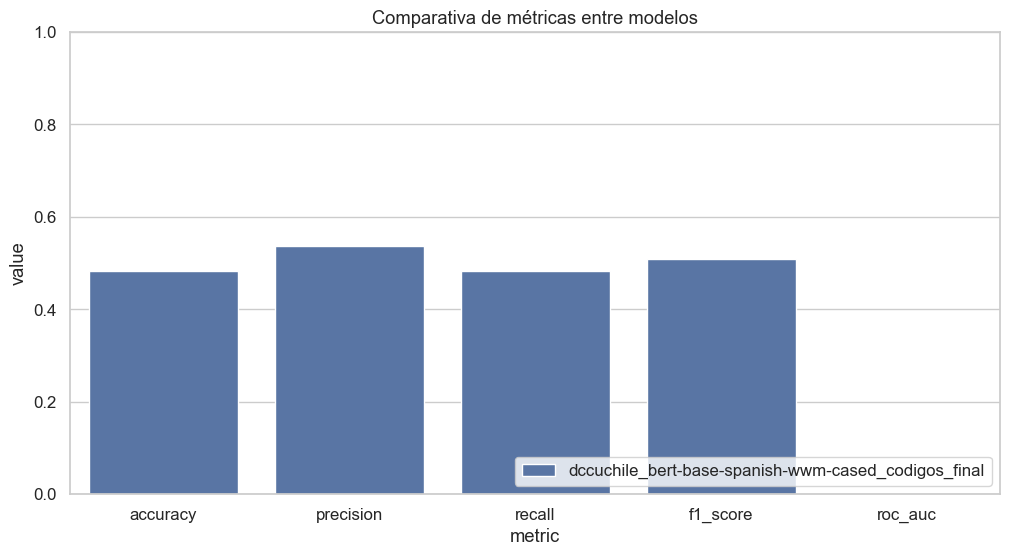

In [61]:
# Gráfico de métricas comparadas
metrics = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]
results_melted = results_df.melt(id_vars=["model"], value_vars=metrics, var_name="metric", value_name="value")

plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x="metric", y="value", hue="model")
plt.title("Comparativa de métricas entre modelos")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

Advertencia: no se puede trazar la curva ROC multiclase para dccuchile_bert-base-spanish-wwm-cased_codigos_final porque devuelve 2 salidas en lugar de 7


Text(0.5, 0, 'False Positive Rate')

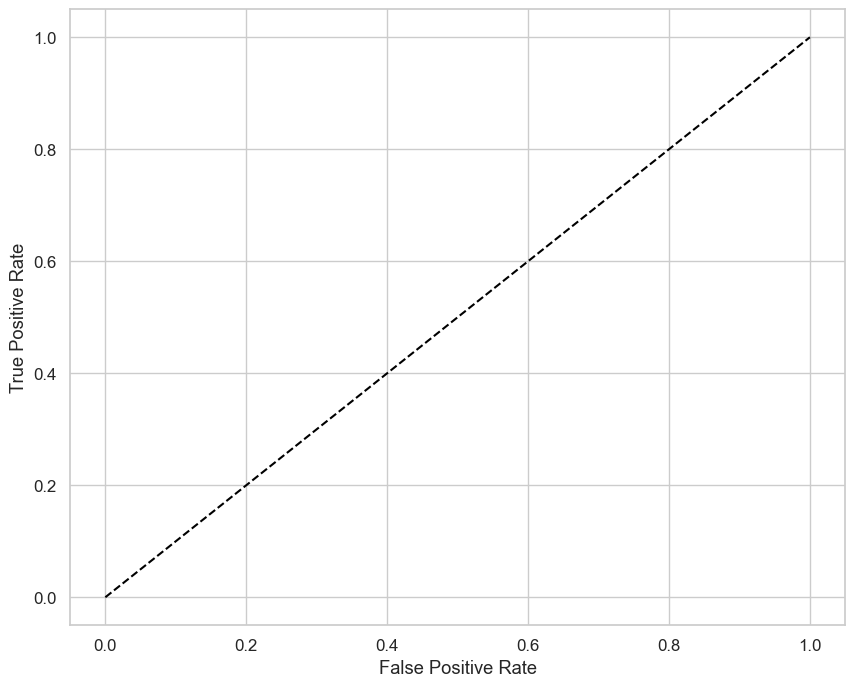

In [62]:
# Curvas ROC
plt.figure(figsize=(10, 8))
for item in roc_data:
    y_true = item["y_true"]
    y_scores = item["y_scores"]
    model_name = item["model"]

    if y_scores.ndim != 2:
        print(f"Advertencia: no se puede trazar la curva ROC para {model_name} porque y_scores no es 2D: {y_scores.shape}")
        continue

    if binary_classification:
        if y_scores.shape[1] < 2:
            print(f"Advertencia: no se puede trazar la curva ROC binaria para {model_name} porque devuelve {y_scores.shape[1]} salidas")
            continue
        fpr, tpr, _ = roc_curve(y_true, y_scores[:, 1])
        roc_auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc_val:.3f})")
    else:
        if y_scores.shape[1] != len(LABELS):
            print(f"Advertencia: no se puede trazar la curva ROC multiclase para {model_name} porque devuelve {y_scores.shape[1]} salidas en lugar de {len(LABELS)}")
            continue
        for class_idx, label in enumerate(LABELS):

            fpr, tpr, _ = roc_curve(y_true == class_idx, y_scores[:, class_idx])
            plt.show()

            roc_auc_val = auc(fpr, tpr)
            plt.legend(loc="lower right", fontsize="small")

            plt.plot(fpr, tpr, alpha=0.6, label=f"{model_name} {label} (AUC = {roc_auc_val:.3f})")
            plt.title("Curvas ROC de los modelos")

plt.ylabel("True Positive Rate")

plt.plot([0, 1], [0, 1], color="black", linestyle="--", label="Aleatorio")
plt.xlabel("False Positive Rate")